<a href="https://colab.research.google.com/github/Amiya-13/mask-detection/blob/main/innovative_project6thsem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow opencv-python matplotlib

In [2]:
!git clone https://github.com/prajnasb/observations.git

Cloning into 'observations'...
remote: Enumerating objects: 1638, done.
remote: Total 1638 (delta 0), reused 0 (delta 0), pack-reused 1638 (from 1)
Receiving objects: 100% (1638/1638), 75.94 MiB | 43.56 MiB/s, done.
Resolving deltas: 100% (19/19), done.
Updating files: 100% (3045/3045), done.


In [3]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [4]:
data_path = "observations/experiements/data/"

categories = ["with_mask", "without_mask"]

data = []
labels = []

IMG_SIZE = 100

for category in categories:
    path = os.path.join(data_path, category)
    label = categories.index(category)

    for img in os.listdir(path):
        img_path = os.path.join(path, img)
        try:
            img_array = cv2.imread(img_path)
            img_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))

            data.append(img_array)
            labels.append(label)
        except:
            pass

data = np.array(data) / 255.0
labels = to_categorical(labels)

print("Data shape:", data.shape)

Data shape: (1376, 100, 100, 3)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

In [6]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(100,100,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,034 (6.61 MB)

 Trainable params: 1,732,034 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=32
)

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 562ms/step - accuracy: 0.7582 - loss: 0.4858 - val_accuracy: 0.9457 - val_loss: 0.1745
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 622ms/step - accuracy: 0.9500 - loss: 0.1390 - val_accuracy: 0.9710 - val_loss: 0.1106
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 569ms/step - accuracy: 0.9700 - loss: 0.0835 - val_accuracy: 0.9819 - val_loss: 0.0681
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 536ms/step - accuracy: 0.9836 - loss: 0.0548 - val_accuracy: 0.9710 - val_loss: 0.0782
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 585ms/step - accuracy: 0.9845 - loss: 0.0444 - val_accuracy: 0.9529 - val_loss: 0.1275
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 522ms/step - accuracy: 0.9855 - loss: 0.0394 - val_accuracy: 0.9819 - val_loss: 0.0831
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 568ms/step - accuracy: 0.9891 - loss: 0.0397 - val_accuracy: 0.9819 - val_loss: 0.0674
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 530ms/step - accuracy: 0.9964 - loss: 0.0140 - val_accu

In [8]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 199ms/step - accuracy: 0.9855 - loss: 0.0780
Accuracy: 0.9855072498321533


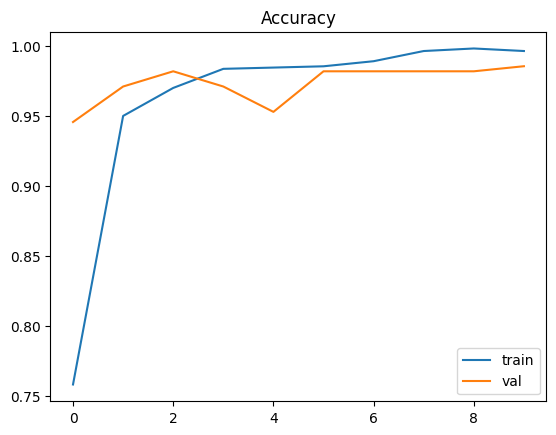

In [9]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

In [15]:
from google.colab import files
import cv2
import numpy as np

# Upload image
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_path)

if img is None:
    print("Error: Image not found")
else:
    img = cv2.resize(img, (100, 100)) / 255.0
    img = np.reshape(img, (1, 100, 100, 3))

    pred = model.predict(img)
    label = np.argmax(pred)

    text = "Mask" if label == 0 else "No Mask"
    print(text)

Saving WIN_20260401_02_36_07_Pro.jpg to WIN_20260401_02_36_07_Pro.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
No Mask
